# Tomography and 3D projections

A projection sums along a ray. Multiple angles enable tomography; a single view has a large nullspace. Filtered backprojection uses a frequency ramp filter and backprojection. A Shepp–Logan phantom is simulated, not a real medical scan.

**Objective:** reconstruct a 2D phantom and prove why one 3D view is ambiguous.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


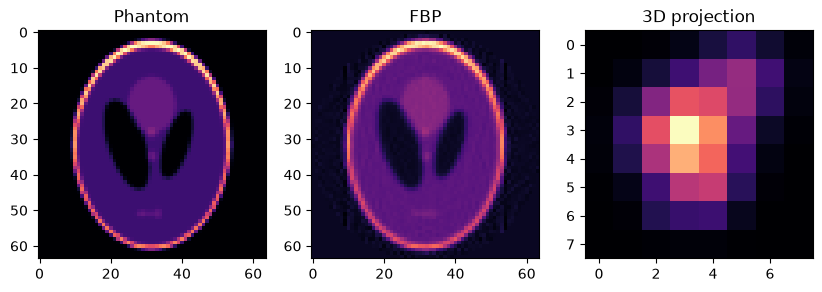

FBP RMSE 0.03920454236659403


In [2]:
from skimage.data import shepp_logan_phantom
from skimage.transform import resize,radon,iradon
phantom=resize(shepp_logan_phantom(),(64,64),anti_aliasing=True); theta=np.linspace(0,180,45,endpoint=False)
sino=radon(phantom,theta=theta,circle=True); rec=iradon(sino,theta=theta,circle=True)
grid=Grid((8,8,8)); volume=simulate(grid,19); P=projections(grid,0)
alternative=volume[::-1].copy()
assert np.allclose(P@volume.ravel(),P@alternative.ravel())
fig,axes=plt.subplots(1,3,figsize=(10,3))
for ax,name,f in zip(axes,['Phantom','FBP','3D projection'],[phantom,rec,(P@volume.ravel()).reshape(8,8)]): ax.imshow(f,cmap='magma'); ax.set_title(name)
plt.show()
print('FBP RMSE',np.sqrt(np.mean((phantom-rec)**2)))


**Exercise:** reduce views to 8, restrict angles to 0–90°, and add noise. Explain streak artifacts. Construct a nonzero vector h with Ph=0. Why is showing a projected volume different from recovering that volume?

See [theory notes](../docs/theory.md) for assumptions and equations.